<html> <h1 style="font-style:italic; color:blue;"> Neural Computing and Deep Learning </h1> </html>

<html> <h1 style="font-style:italic; color:blue;"> Week-7 </h1> </html>


<html> <h2 style="font-style:italic; color:blue;"> Transfer Learning </h2> </html>



<html> <h3 style="font-style:italic; color:blue;"> CIFAR10 Transfer Learning based Classifier </h3> </html>


<html> <h3 style="font-style:italic; color:blue;"> VGG16 and VGG19</h3> </html>


##### This notebook outlines the steps to build a classifier to leverage concepts of Transfer Learning by utilising a pretrained Deep-CNNs.


<html> <h4 style="font-style:italic; color:blue;"> Just run the next cell using 'Ctrl' + 'Enter' </h4> </html>

In [1]:
# For Google Colab only!

!cat /proc/driver/nvidia/gpus/0000:00:04.0/information

Model: 		 Tesla T4
IRQ:   		 11
GPU UUID: 	 GPU-7ff9c782-d6e4-d237-988a-4d7b930fd0d1
Video BIOS: 	 90.04.a7.00.01
Bus Type: 	 PCI
DMA Size: 	 47 bits
DMA Mask: 	 0x7fffffffffff
Bus Location: 	 0000:00:04.0
Device Minor: 	 0
GPU Firmware: 	 580.82.07
GPU Excluded:	 No



### Restart the Kernel

_________________________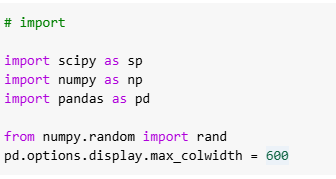

In [2]:
import scipy as sp
import numpy as np
import pandas as pd

from numpy.random import rand
pd.options.display.max_colwidth = 600

import tensorflow as tf
from tensorflow import keras
from keras import callbacks
from keras import optimizers
from keras.datasets import cifar10

from keras import Model
from keras.applications import vgg16 as vgg
from keras.layers import Dropout, Flatten, Dense, GlobalAveragePooling2D, BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import to_categorical

from sklearn import preprocessing
from sklearn.metrics import roc_curve, auc, precision_recall_curve
from sklearn.model_selection import train_test_split

from IPython.display import display, HTML
import warnings
warnings.filterwarnings('ignore')

In [3]:
import matplotlib.pyplot as plt
params = {'legend.fontsize': 'x-large',
          'figure.figsize': (15, 5),
          'axes.labelsize' : 'x-large',
          'axes.titlesize': 'x-large',
          'xtick.labelsize' : 'x-large',
          'ytick.labelsize' : 'x-large'
          }

plt.rcParams.update(params)

### Load and manipulate the DataSet

In [4]:
BATCH_SIZE = 32
EPOCHS = 40
NUM_CLASSES = 10
LEARNING_RATE = 1e-4
MOMENTUM = 0.9

In [5]:
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()

In [6]:
x_train.shape, x_test.shape, y_train.shape, y_test.shape

((50000, 32, 32, 3), (10000, 32, 32, 3), (50000, 1), (10000, 1))

In [7]:
X_train, X_val, y_train, y_val = train_test_split(x_train, y_train, test_size=0.15, stratify=np.array(y_train))

Checks for free memory:

In [8]:
tf.keras.backend.clear_session()

In [9]:
!free -h

               total        used        free      shared  buff/cache   available
Mem:            12Gi       2.1Gi       7.5Gi       2.0Mi       3.1Gi        10Gi
Swap:             0B          0B          0B


In [10]:
y_train = to_categorical(y_train, NUM_CLASSES)
y_test = to_categorical(y_test, NUM_CLASSES)

In [11]:
y_val = to_categorical(y_val, NUM_CLASSES)

In [12]:
y_train.shape, y_val.shape, y_test.shape

((42500, 10), (7500, 10), (10000, 10))

### Preprocessing

In [13]:
# Since we are about to use VGG16 and VGG19as a feature extractor, the minimum size of an image its take is 48x48.
# We utilize ```scipy`` to resize images to required dimensions


In [14]:
X_train = tf.data.Dataset.from_tensor_slices((X_train, y_train))
X_val = tf.data.Dataset.from_tensor_slices((X_val, y_val))
X_test = tf.data.Dataset.from_tensor_slices((x_test, y_test))


def preprocess_image(image, label):
  image = tf.image.resize(image, (48,48))
  return image, label

X_train = X_train.map(preprocess_image)
X_val = X_val.map(preprocess_image)
X_test = X_test.map(preprocess_image)

X_train = np.array([image.numpy() for image, label in X_train])
X_val = np.array([image.numpy() for image, label in X_val])
X_test = np.array([image.numpy() for image, label in X_test])

In [15]:
!free -h


               total        used        free      shared  buff/cache   available
Mem:            12Gi       4.4Gi       4.9Gi        12Mi       3.4Gi       8.0Gi
Swap:             0B          0B          0B


# Create VGG19 Model

- Load VGG16 without the top classification layer
- Create a custom classifier
- Stack both models on top of each other


In [16]:
base_model = vgg.VGG16(weights='imagenet',
                       include_top = False,
                       input_shape=(48,48,3)
                       )

In [17]:
base_model.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 48, 48, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 48, 48, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 48, 48, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 24, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 24, 24, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 12, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 12, 12, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 12, 12, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 6, 6, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 6, 6, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 6, 6, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 3, 3, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 3, 3, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 3, 3, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 3, 3, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 1, 1, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

In [18]:
last = base_model.get_layer('block3_pool').output

In [19]:
x = GlobalAveragePooling2D()(last)
x = BatchNormalization()(x)
x = Dense(256, activation='relu')(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.6)(x)
pred = Dense(NUM_CLASSES, activation='softmax')(x)
model = Model(inputs=base_model.input, outputs=pred)

In [20]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 48, 48, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 48, 48, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 48, 48, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 24, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 24, 24, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 12, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 12, 12, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 12, 12, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,870,666 (7.14 MB)

 Trainable params: 1,870,154 (7.13 MB)

 Non-trainable params: 512 (2.00 KB)

In [21]:
for layer in base_model.layers:
  layer.trainable = False

In [22]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 48, 48, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 48, 48, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 48, 48, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 24, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 24, 24, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 12, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 12, 12, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 12, 12, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,870,666 (7.14 MB)

 Trainable params: 134,666 (526.04 KB)

 Non-trainable params: 1,736,000 (6.62 MB)

In [23]:
model.compile(optimizer=optimizers.Adam(learning_rate=LEARNING_RATE), metrics=['accuracy'], loss='categorical_crossentropy')

In [24]:
from tensorflow.keras.callbacks import EarlyStopping


In [25]:
# Your code to create an object early-stop

# Use the patience parameter equal to the last digit in your SID.
# However,
# If the last digit of your SID = 0, then assign patience=10
# If the last digit of your SID = 1, then assign patience=11
# If the last digit of your SID = 2, then assign patience=12
# If the last digit of your SID = 3, then assign patience=13

# For example, your SID = 22984879, then patience=9
# One more example: your SID = 22984883, then patience=13

# LAST_DIGIT_IN_YOUR_SID =

early_stop = EarlyStopping(monitor='val_loss',patience=5)


### Data Augmentation


To help model generalize and overcome the limitations of a small dataset, we prepare augmented datasets using keras  utilities


In [26]:
train_datagen = ImageDataGenerator(rescale=1./255, horizontal_flip=False)

In [27]:
train_datagen.fit(X_train)
train_data = train_datagen.flow(X_train, y_train, batch_size=BATCH_SIZE)

In [28]:
val_datagen = ImageDataGenerator(rescale=1./255, horizontal_flip=False)
val_datagen.fit(X_val)
val_data = val_datagen.flow(X_val, y_val, batch_size=BATCH_SIZE)

### Train the Model

<html> <h4 style="font-style:italic; color:blue;"> Just run the next cell
</h4> </html>

In [29]:
train_steps_per_epoch = X_train.shape[0] // BATCH_SIZE
val_steps_per_epoch = X_val.shape[0] // BATCH_SIZE

In [30]:
history = model.fit(train_data, steps_per_epoch=train_steps_per_epoch, validation_data=val_data, validation_steps= val_steps_per_epoch, epochs=EPOCHS, callbacks=[early_stop], verbose=1)

Epoch 1/40
1328/1328 ━━━━━━━━━━━━━━━━━━━━ 22s 12ms/step - accuracy: 0.3217 - loss: 1.9333 - val_accuracy: 0.6047 - val_loss: 1.1730
Epoch 2/40
1328/1328 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.4375 - loss: 1.4293 - val_accuracy: 0.6050 - val_loss: 1.1720
Epoch 3/40
1328/1328 ━━━━━━━━━━━━━━━━━━━━ 13s 10ms/step - accuracy: 0.5445 - loss: 1.3047 - val_accuracy: 0.6532 - val_loss: 1.0120
Epoch 4/40
1328/1328 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.5938 - loss: 1.2035 - val_accuracy: 0.6524 - val_loss: 1.0126
Epoch 5/40
1328/1328 ━━━━━━━━━━━━━━━━━━━━ 14s 10ms/step - accuracy: 0.5979 - loss: 1.1557 - val_accuracy: 0.6768 - val_loss: 0.9314
Epoch 6/40
1328/1328 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.6875 - loss: 1.0093 - val_accuracy: 0.6772 - val_loss: 0.9305
Epoch 7/40
1328/1328 ━━━━━━━━━━━━━━━━━━━━ 14s 11ms/step - accuracy: 0.6385 - loss: 1.0460 - val_accuracy: 0.6972 - val_loss: 0.8810
Epoch 8/40
1328/1328 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.6875 - loss: 0

### Analyse Model Performance

<html> <h4 style="font-style:italic; color:blue;"> Just run the next cell using </h4> </html>

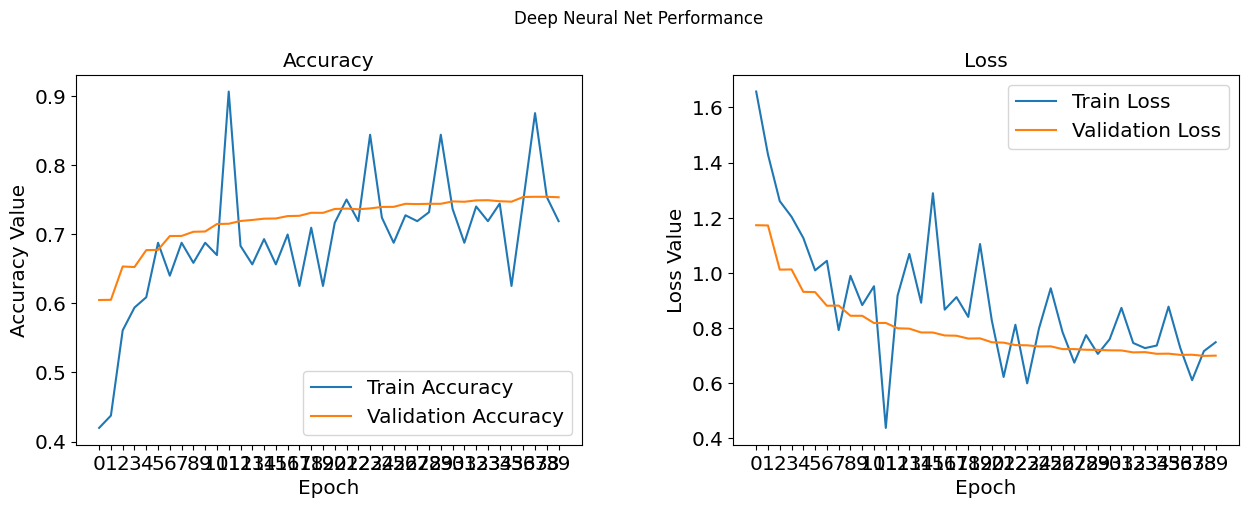

In [31]:
f, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
t = f.suptitle('Deep Neural Net Performance', fontsize=12)
f.subplots_adjust(top=0.85, wspace=0.3)

epochs = list(range(len(history.history['accuracy'])))
ax1.plot(epochs, history.history['accuracy'], label='Train Accuracy')
ax1.plot(epochs, history.history['val_accuracy'], label='Validation Accuracy')
ax1.set_xticks(epochs)
ax1.set_ylabel('Accuracy Value')
ax1.set_xlabel('Epoch')
ax1.set_title('Accuracy')
l1 = ax1.legend(loc="best")

ax2.plot(epochs, history.history['loss'], label='Train Loss')
ax2.plot(epochs, history.history['val_loss'], label='Validation Loss')
ax2.set_xticks(epochs)
ax2.set_ylabel('Loss Value')
ax2.set_xlabel('Epoch')
ax2.set_title('Loss')
l2 = ax2.legend(loc="best")


In [32]:
predictions = model.predict(X_test/255)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step


In [33]:
test_labels = list(y_test.squeeze())
predictions = list(predictions.argmax(axis=1))

In [34]:
from sklearn.metrics import classification_report

In [35]:
y_test.argmax(axis=1)

array([3, 8, 8, ..., 5, 1, 7])

In [36]:
error_metrics_report = classification_report(y_test.argmax(axis=1), predictions)
print(error_metrics_report)

              precision    recall  f1-score   support

           0       0.82      0.80      0.81      1000
           1       0.83      0.85      0.84      1000
           2       0.68      0.69      0.69      1000
           3       0.59      0.58      0.59      1000
           4       0.72      0.69      0.70      1000
           5       0.68      0.65      0.66      1000
           6       0.74      0.83      0.79      1000
           7       0.80      0.78      0.79      1000
           8       0.82      0.86      0.84      1000
           9       0.84      0.80      0.82      1000

    accuracy                           0.75     10000
   macro avg       0.75      0.75      0.75     10000
weighted avg       0.75      0.75      0.75     10000



In [37]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [38]:
PretrainedModels = ['VGG-16', 'VGG_19']

In [39]:
ErrorMetrics = []
Accuracy = []
Precision = []
Recall = []
F1_Score = []

In [40]:
Accuracy.append(accuracy_score(y_test.argmax(axis=1),predictions))
Precision.append(precision_score(y_test.argmax(axis=1),predictions,average='macro'))
Recall.append(recall_score(y_test.argmax(axis=1),predictions,average='macro'))
F1_Score.append(f1_score(y_test.argmax(axis=1),predictions,average='macro'))

print(Accuracy, '\n', Precision, '\n', Recall, '\n', F1_Score)

[0.7532] 
 [0.7526181216524397] 
 [0.7532] 
 [0.7524080210701906]


### Visualise Predictions

<html> <h4 style="font-style:italic; color:blue;"> Just run the next 2 cells using 'Ctrl' + 'Enter' </h4> </html>

In [41]:
#label_dict = {0:'airplane',
#             1:'automobile',
#             2:'bird',
#             3:'cat',
#             4:'deer',
#             5:'dog',
#             6:'frog',
#             7:'horse',
#             8:'ship',
#             9:'truck'}

classes=['airplane', 'automobile', 'bird', 'cat', 'deer',
 'dog', 'frog', 'houre', 'ship', 'truck']

In [42]:
# Graph this to look at the full set of 10 class predictions.


def plot_image(i,predictions_array, true_label, img):
    predictions_array, true_label, img = predictions_array, true_label[i], img[i]
    plt.grid(False)
    plt.xticks([])
    plt.yticks([])

    plt.imshow(img, cmap=plt.cm.binary)

    predicted_label = np.argmax(predictions_array)
    if predicted_label == true_label:
        color = 'blue'
    else:
        color = 'red'

    plt.xlabel("{} {:2.0f}% ({})".format(label_dict[predicted_label],
                                    100 * np.max(predictions_array),
                                    label_dict[true_label]),
                                    color=color)

___________________________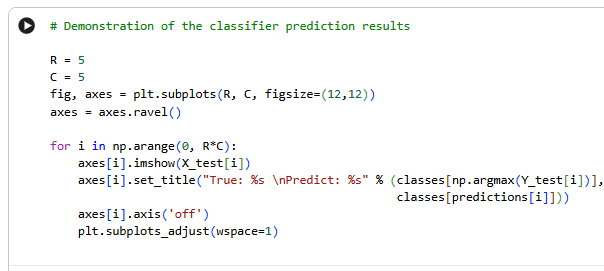

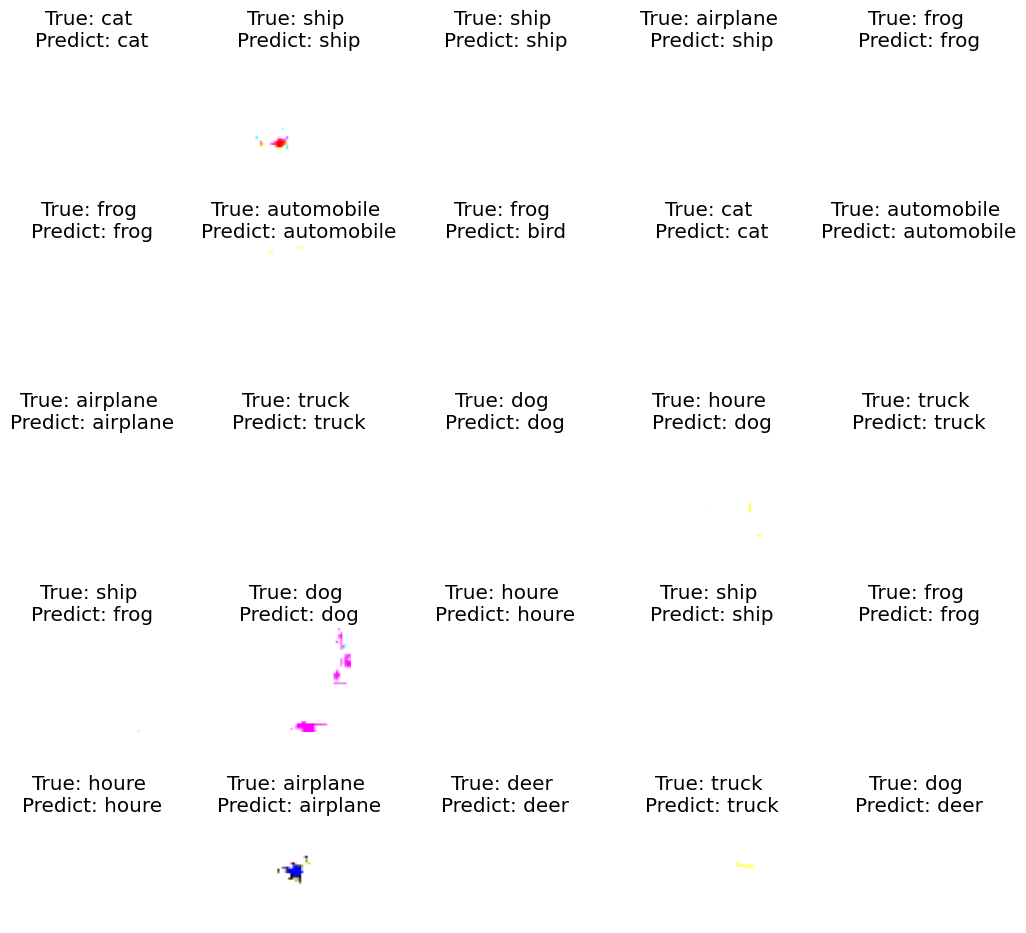

In [43]:
R = 5
C = 5
fig, axes = plt.subplots(R, C, figsize=(12, 12))
axes = axes.ravel()

for i in np.arange(0, R*C):
  axes[i].imshow(X_test[i])
  axes[i].set_title("True: %s \nPredict: %s" % (classes[np.argmax(y_test[i])], classes[predictions[i]]))
  axes[i].axis('off')
  plt.subplots_adjust(wspace=1)

# Create VGG19 Model

- Load VGG19 without the top classification layer
- Create a custom classifier
- Stack both models on top of each other


In [44]:
base_model_2 = keras.applications.VGG19(weights='imagenet',
                       include_top = False,
                       input_shape=(48,48,3)
                       )

base_model_2.summary()

Model: "vgg19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 48, 48, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 48, 48, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 48, 48, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 24, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 24, 24, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 12, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 12, 12, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 12, 12, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv4 (Conv2D)           │ (None, 12, 12, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 6, 6, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 6, 6, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 6, 6, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv4 (Conv2D)           │ (None, 6, 6, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 3, 3, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 3, 3, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 3, 3, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 3, 3, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv4 (Conv2D)           │ (None, 3, 3, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 1, 1, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,024,384 (76.39 MB)

 Trainable params: 20,024,384 (76.39 MB)

 Non-trainable params: 0 (0.00 B)

In [45]:
last = base_model.get_layer('block3_pool').output

In [46]:
x = GlobalAveragePooling2D()(last)
x = BatchNormalization()(x)
x = Dense(256, activation='relu')(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.6)(x)
pred = Dense(NUM_CLASSES, activation='softmax')(x)
model2 = Model(inputs=base_model.input, outputs=pred)

In [47]:
for layer in base_model_2.layers:
  layer.trainable = False

In [48]:
model2.compile(optimizer=optimizers.Adam(learning_rate=LEARNING_RATE), metrics=['accuracy'], loss='categorical_crossentropy')

### Train the Model_2

In [49]:
history_2 = model2.fit(train_data, steps_per_epoch=train_steps_per_epoch, validation_data=val_data, validation_steps= val_steps_per_epoch, epochs=EPOCHS, callbacks=[early_stop], verbose=1)

Epoch 1/40
1328/1328 ━━━━━━━━━━━━━━━━━━━━ 20s 12ms/step - accuracy: 0.3170 - loss: 1.9544 - val_accuracy: 0.6028 - val_loss: 1.1739
Epoch 2/40
1328/1328 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.5625 - loss: 1.3923 - val_accuracy: 0.6032 - val_loss: 1.1741
Epoch 3/40
1328/1328 ━━━━━━━━━━━━━━━━━━━━ 14s 11ms/step - accuracy: 0.5524 - loss: 1.2978 - val_accuracy: 0.6514 - val_loss: 1.0076
Epoch 4/40
1328/1328 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.6875 - loss: 1.0738 - val_accuracy: 0.6516 - val_loss: 1.0075
Epoch 5/40
1328/1328 ━━━━━━━━━━━━━━━━━━━━ 14s 11ms/step - accuracy: 0.6042 - loss: 1.1427 - val_accuracy: 0.6832 - val_loss: 0.9294
Epoch 6/40
1328/1328 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.5938 - loss: 1.1820 - val_accuracy: 0.6832 - val_loss: 0.9302
Epoch 7/40
1328/1328 ━━━━━━━━━━━━━━━━━━━━ 14s 10ms/step - accuracy: 0.6324 - loss: 1.0641 - val_accuracy: 0.6962 - val_loss: 0.8795
Epoch 8/40
1328/1328 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.7188 - loss: 0

### Analyse Model Performance

<html> <h4 style="font-style:italic; color:blue;"> Just run the next cell using 'Ctrl' + 'Enter' </h4> </html>

Find 4 differences in the code with the similar code for VGG16

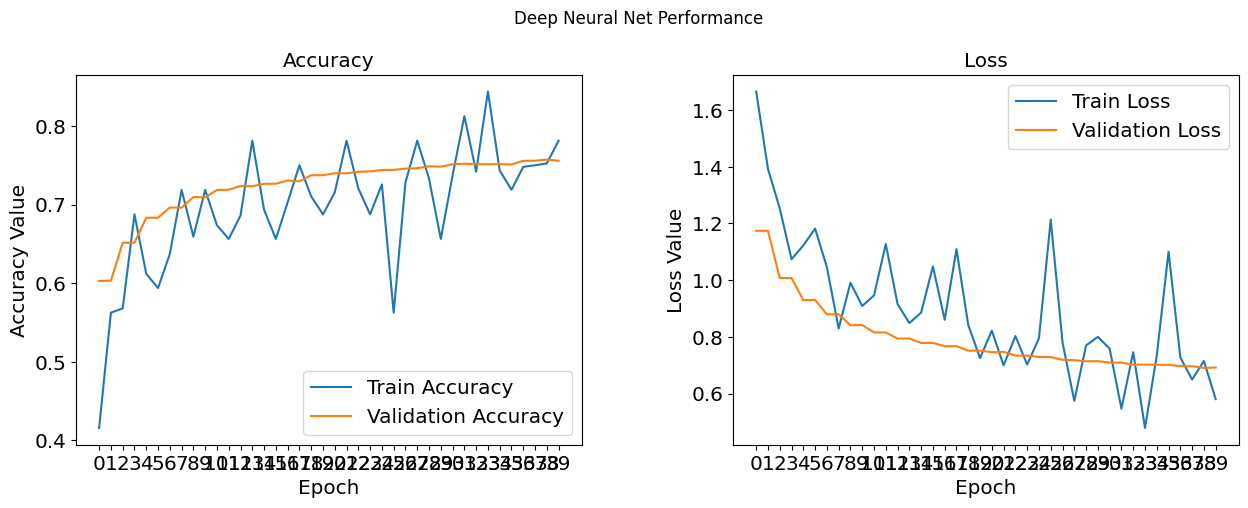

In [50]:
f, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
t = f.suptitle('Deep Neural Net Performance', fontsize=12)
f.subplots_adjust(top=0.85, wspace=0.3)

epochs = list(range(len(history_2.history['accuracy'])))
ax1.plot(epochs, history_2.history['accuracy'], label='Train Accuracy')
ax1.plot(epochs, history_2.history['val_accuracy'], label='Validation Accuracy')
ax1.set_xticks(epochs)
ax1.set_ylabel('Accuracy Value')
ax1.set_xlabel('Epoch')
ax1.set_title('Accuracy')
l1 = ax1.legend(loc="best")

ax2.plot(epochs, history_2.history['loss'], label='Train Loss')
ax2.plot(epochs, history_2.history['val_loss'], label='Validation Loss')
ax2.set_xticks(epochs)
ax2.set_ylabel('Loss Value')
ax2.set_xlabel('Epoch')
ax2.set_title('Loss')
l2 = ax2.legend(loc="best")


In [51]:
predictions2 = model2.predict(X_test/255)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step


In [52]:
test_labels = list(y_test.squeeze())
predictions2 = list(predictions2.argmax(axis=1))

In [53]:
error_metrics_report2 = classification_report(y_test.argmax(axis=1), predictions2)
print(error_metrics_report2)

              precision    recall  f1-score   support

           0       0.80      0.80      0.80      1000
           1       0.82      0.87      0.84      1000
           2       0.69      0.67      0.68      1000
           3       0.61      0.59      0.60      1000
           4       0.71      0.71      0.71      1000
           5       0.69      0.65      0.67      1000
           6       0.77      0.83      0.80      1000
           7       0.79      0.79      0.79      1000
           8       0.84      0.85      0.84      1000
           9       0.83      0.80      0.81      1000

    accuracy                           0.76     10000
   macro avg       0.75      0.76      0.76     10000
weighted avg       0.75      0.76      0.76     10000



In [54]:
Accuracy.append(accuracy_score(y_test.argmax(axis=1),predictions2))
Precision.append(precision_score(y_test.argmax(axis=1),predictions2,average='macro'))
Recall.append(recall_score(y_test.argmax(axis=1),predictions2,average='macro'))
F1_Score.append(f1_score(y_test.argmax(axis=1),predictions2,average='macro'))

print(Accuracy, '\n', Precision, '\n', Recall, '\n', F1_Score)

[0.7532, 0.7561] 
 [0.7526181216524397, 0.7549160053964077] 
 [0.7532, 0.7561] 
 [0.7524080210701906, 0.7552449823051579]


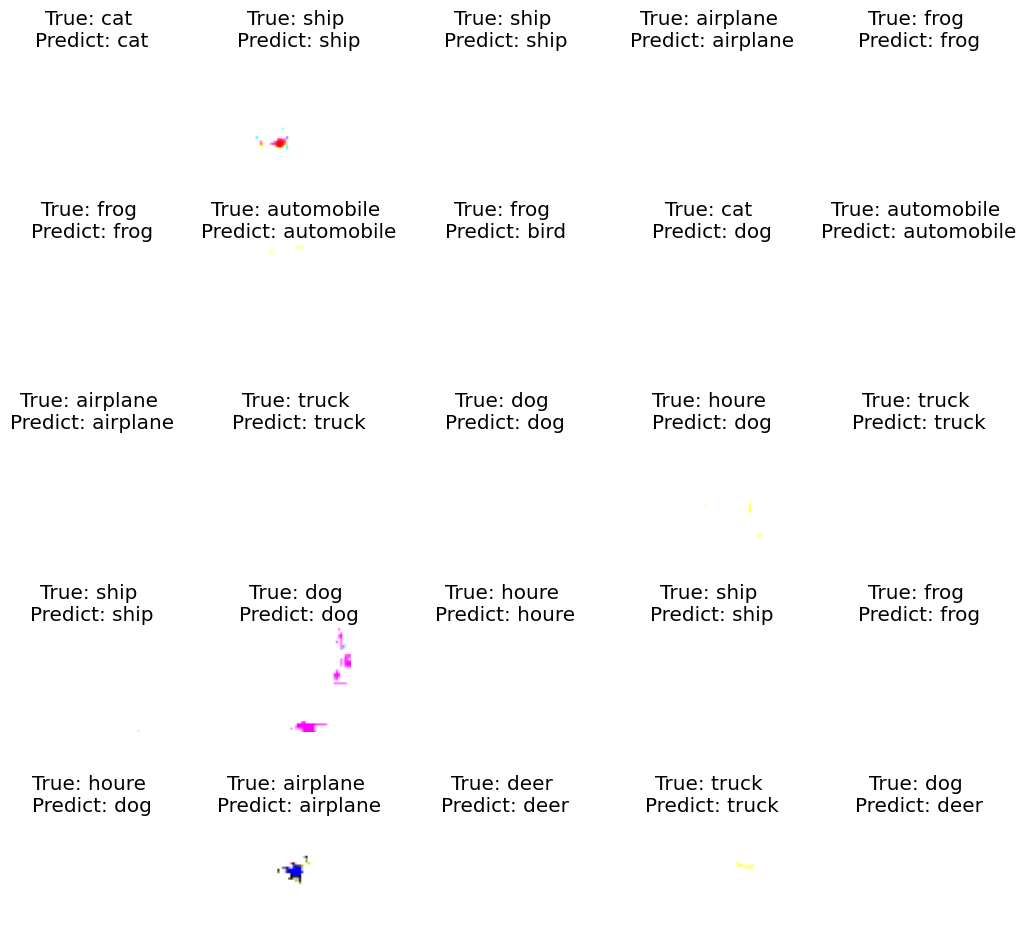

In [55]:
R = 5
C = 5
fig, axes = plt.subplots(R, C, figsize=(12, 12))
axes = axes.ravel()

for i in np.arange(0, R*C):
  axes[i].imshow(X_test[i])
  axes[i].set_title("True: %s \nPredict: %s" % (classes[np.argmax(y_test[i])], classes[predictions2[i]]))
  axes[i].axis('off')
  plt.subplots_adjust(wspace=1)

In [56]:
ErrorMetrics.append(Accuracy)
ErrorMetrics.append(Precision)
ErrorMetrics.append(Recall)
ErrorMetrics.append(F1_Score)

<html> <h2 style="font-style:bold; color:red;"> Lab Logbook requirements </h2> </html>

### 1. Plot graphs for Accuracy and Loss Function for VGG16 and VGG19 (4 graphs in total).
### 2. Based on this analysis, determine the optimal number of epochs for training your VGG16 and VGG19 models.
### 3. Copy your early-stop code

### 4. Add the final Performance Table

### 5. Plot the performance comparing histogram of VGG16 and VGG19

# Create Inception Model

<html> <h2 style="font-style:bold; color:red;"> Optional.
Extra mark. </h2> </html>

1. Use the base_model 'Inception-V3' pre-trained neural network model.
2. Add Inception-V3 results to the Performance table and Performance comparing histogram.

In [57]:
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()
X_train, X_val, y_train, y_val = train_test_split(x_train, y_train, test_size=0.15, stratify=np.array(y_train))
y_train = to_categorical(y_train, NUM_CLASSES)
y_test = to_categorical(y_test, NUM_CLASSES)
y_val = to_categorical(y_val, NUM_CLASSES)

In [58]:
base_model3 = keras.applications.InceptionV3(weights='imagenet',
                                             include_top=False,
                                             input_shape=(75,75,3),
                                             )
base_model3.summary()

Model: "inception_v3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 75, 75, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 37, 37,    │        864 │ input_layer_2[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 37, 37,    │         96 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 37, 37,    │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 35, 35,    │      9,216 │ activation[0][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 35, 35,    │         96 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 35, 35,    │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 35, 35,    │     18,432 │ activation_1[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 35, 35,    │        192 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 35, 35,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 17, 17,    │          0 │ activation_2[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 17, 17,    │      5,120 │ max_pooling2d[0]… │
│                     │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 17, 17,    │        240 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 17, 17,    │          0 │ batch_normalizat… │
│ (Activation)        │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 15, 15,    │    138,240 │ activation_3[0][… │
│                     │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 15, 15,    │        576 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_4        │ (None, 15, 15,    │          0 │ batch_normalizat

 Total params: 21,802,784 (83.17 MB)

 Trainable params: 21,768,352 (83.04 MB)

 Non-trainable params: 34,432 (134.50 KB)

In [59]:
last = base_model3.get_layer('mixed7').output

x = GlobalAveragePooling2D()(last)
x = BatchNormalization()(x)
x = Dense(256, activation='relu')(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.6)(x)
outputs = Dense(NUM_CLASSES, activation='softmax')(x)
model3 = Model(inputs=base_model3.input, outputs=outputs)
model3.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 75, 75, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 37, 37,    │        864 │ input_layer_2[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 37, 37,    │         96 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 37, 37,    │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 35, 35,    │      9,216 │ activation[0][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 35, 35,    │         96 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 35, 35,    │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 35, 35,    │     18,432 │ activation_1[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 35, 35,    │        192 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 35, 35,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 17, 17,    │          0 │ activation_2[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 17, 17,    │      5,120 │ max_pooling2d[0]… │
│                     │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 17, 17,    │        240 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 17, 17,    │          0 │ batch_normalizat… │
│ (Activation)        │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 15, 15,    │    138,240 │ activation_3[0][… │
│                     │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 15, 15,    │        576 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_4        │ (None, 15, 15,    │          0 │ batch_normalizat

 Total params: 9,243,562 (35.26 MB)

 Trainable params: 9,223,210 (35.18 MB)

 Non-trainable params: 20,352 (79.50 KB)

In [60]:
for layer in base_model3.layers:
  layer.trainable = False

In [61]:
model3.compile(loss='categorical_crossentropy', metrics=['accuracy'], optimizer=optimizers.Adam(learning_rate=LEARNING_RATE))

In [62]:
"""from skimage import transform
X_train = np.array([transform.resize(x, (75,75)) for x in X_train])"""

'from skimage import transform\nX_train = np.array([transform.resize(x, (75,75)) for x in X_train])'

In [63]:
"""
X_val = np.array([transform.resize(x, (75,75)) for x in X_val])
X_test = np.array([transform.resize(x, (75,75)) for x in x_test])"""

'\nX_val = np.array([transform.resize(x, (75,75)) for x in X_val])\nX_test = np.array([transform.resize(x, (75,75)) for x in x_test])'

In [64]:
X_train = tf.data.Dataset.from_tensor_slices((X_train, y_train))
X_val = tf.data.Dataset.from_tensor_slices((X_val, y_val))
X_test = tf.data.Dataset.from_tensor_slices((x_test, y_test))


def preprocess_image(image, label):
  image = tf.image.resize(image, (75,75))
  return image, label

X_train = X_train.map(preprocess_image)
X_val = X_val.map(preprocess_image)
X_test = X_test.map(preprocess_image)

X_train = np.array([image.numpy() for image, label in X_train])
X_val = np.array([image.numpy() for image, label in X_val])
X_test = np.array([image.numpy() for image, label in X_test])

In [65]:
train_datagen.fit(X_train)
train_data = train_datagen.flow(X_train, y_train, batch_size=BATCH_SIZE)

In [66]:
val_datagen = ImageDataGenerator(rescale=1./255, horizontal_flip=False)
val_datagen.fit(X_val)
val_data = val_datagen.flow(X_val, y_val, batch_size=BATCH_SIZE)

In [67]:
history3= model3.fit(train_data, steps_per_epoch=train_steps_per_epoch, validation_data=val_data, validation_steps= val_steps_per_epoch, epochs=EPOCHS, callbacks=[early_stop], verbose=1)

Epoch 1/40
1328/1328 ━━━━━━━━━━━━━━━━━━━━ 45s 23ms/step - accuracy: 0.3784 - loss: 1.8077 - val_accuracy: 0.6959 - val_loss: 0.9000
Epoch 2/40
1328/1328 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6875 - loss: 1.0162 - val_accuracy: 0.6963 - val_loss: 0.9000
Epoch 3/40
1328/1328 ━━━━━━━━━━━━━━━━━━━━ 19s 15ms/step - accuracy: 0.6519 - loss: 1.0180 - val_accuracy: 0.7342 - val_loss: 0.7838
Epoch 4/40
1328/1328 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.5938 - loss: 1.1533 - val_accuracy: 0.7345 - val_loss: 0.7824
Epoch 5/40
1328/1328 ━━━━━━━━━━━━━━━━━━━━ 20s 15ms/step - accuracy: 0.6975 - loss: 0.8798 - val_accuracy: 0.7505 - val_loss: 0.7300
Epoch 6/40
1328/1328 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6875 - loss: 0.7976 - val_accuracy: 0.7504 - val_loss: 0.7293
Epoch 7/40
1328/1328 ━━━━━━━━━━━━━━━━━━━━ 20s 15ms/step - accuracy: 0.7186 - loss: 0.8118 - val_accuracy: 0.7564 - val_loss: 0.7005
Epoch 8/40
1328/1328 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6875 - loss: 0

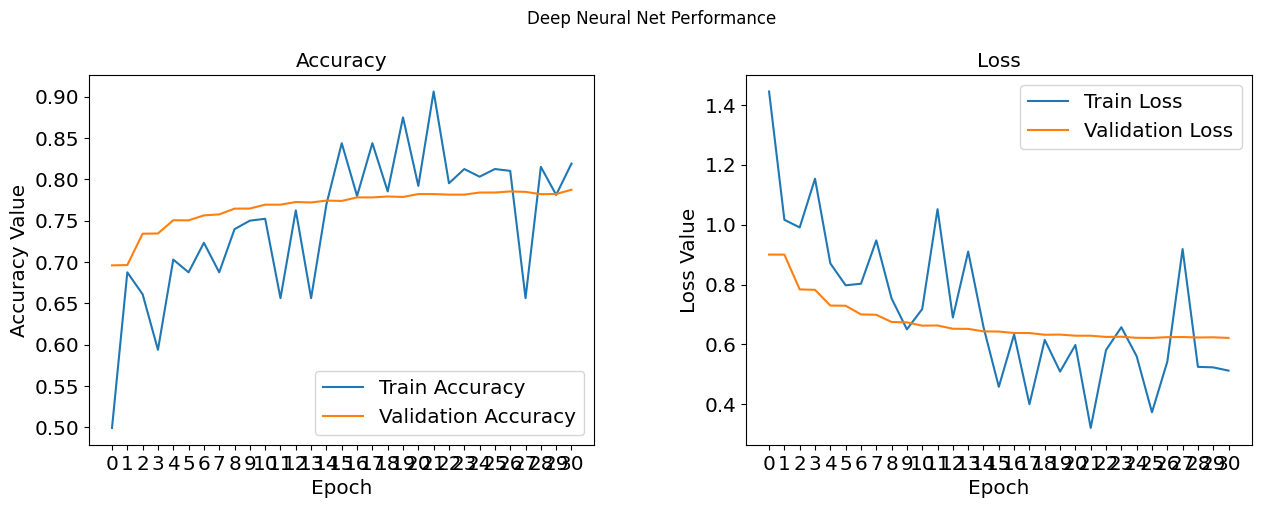

In [68]:
f, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
t = f.suptitle('Deep Neural Net Performance', fontsize=12)
f.subplots_adjust(top=0.85, wspace=0.3)

epochs = list(range(len(history3.history['accuracy'])))
ax1.plot(epochs, history3.history['accuracy'], label='Train Accuracy')
ax1.plot(epochs, history3.history['val_accuracy'], label='Validation Accuracy')
ax1.set_xticks(epochs)
ax1.set_ylabel('Accuracy Value')
ax1.set_xlabel('Epoch')
ax1.set_title('Accuracy')
l1 = ax1.legend(loc="best")

ax2.plot(epochs, history3.history['loss'], label='Train Loss')
ax2.plot(epochs, history3.history['val_loss'], label='Validation Loss')
ax2.set_xticks(epochs)
ax2.set_ylabel('Loss Value')
ax2.set_xlabel('Epoch')
ax2.set_title('Loss')
l2 = ax2.legend(loc="best")


In [69]:
predictions3 = model3.predict(X_test/255)

test_labels = list(y_test.squeeze())
predictions3 = list(predictions3.argmax(axis=1))

error_metrics_report3 = classification_report(y_test.argmax(axis=1), predictions3)
print(error_metrics_report3)

313/313 ━━━━━━━━━━━━━━━━━━━━ 13s 28ms/step
              precision    recall  f1-score   support

           0       0.81      0.82      0.82      1000
           1       0.85      0.87      0.86      1000
           2       0.74      0.71      0.72      1000
           3       0.64      0.58      0.61      1000
           4       0.72      0.75      0.73      1000
           5       0.72      0.70      0.71      1000
           6       0.76      0.83      0.79      1000
           7       0.80      0.82      0.81      1000
           8       0.86      0.87      0.86      1000
           9       0.85      0.84      0.84      1000

    accuracy                           0.78     10000
   macro avg       0.78      0.78      0.78     10000
weighted avg       0.78      0.78      0.78     10000



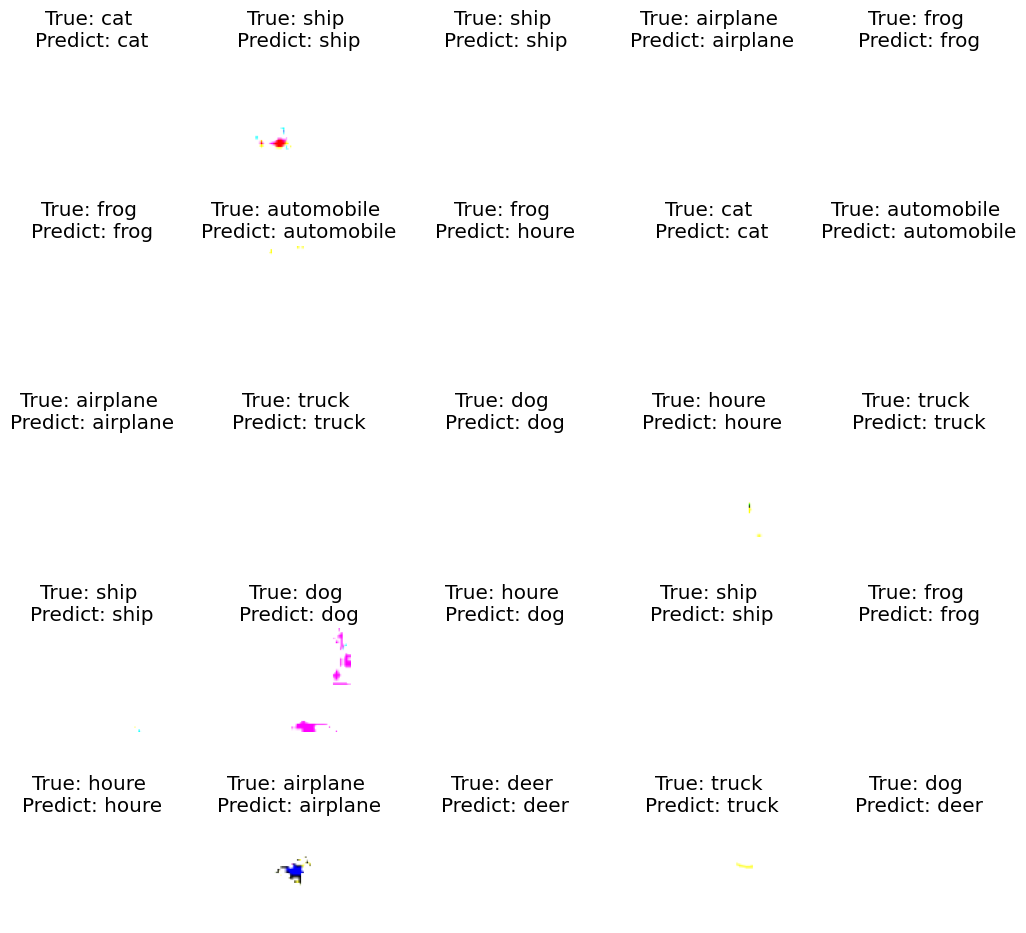

In [70]:
R = 5
C = 5
fig, axes = plt.subplots(R, C, figsize=(12, 12))
axes = axes.ravel()

for i in np.arange(0, R*C):
  axes[i].imshow(X_test[i])
  axes[i].set_title("True: %s \nPredict: %s" % (classes[np.argmax(y_test[i])], classes[predictions3[i]]))
  axes[i].axis('off')
  plt.subplots_adjust(wspace=1)

In [71]:
Accuracy.append(accuracy_score(y_test.argmax(axis=1),predictions3))
Precision.append(precision_score(y_test.argmax(axis=1),predictions3,average='macro'))
Recall.append(recall_score(y_test.argmax(axis=1),predictions3,average='macro'))
F1_Score.append(f1_score(y_test.argmax(axis=1),predictions3,average='macro'))

print(Accuracy, '\n', Precision, '\n', Recall, '\n', F1_Score)

[0.7532, 0.7561, 0.7773] 
 [0.7526181216524397, 0.7549160053964077, 0.7757922321601501] 
 [0.7532, 0.7561, 0.7773] 
 [0.7524080210701906, 0.7552449823051579, 0.7761687256710448]


In [72]:
ErrorMetrics.append(Accuracy)
ErrorMetrics.append(Precision)
ErrorMetrics.append(Recall)
ErrorMetrics.append(F1_Score)

In [73]:
ErrorMetrics_df = pd.DataFrame(ErrorMetrics)
ErrorMetrics_df

,0,1,2
0,0.753200,0.756100,0.777300
1,0.752618,0.754916,0.775792
2,0.753200,0.756100,0.777300
3,0.752408,0.755245,0.776169
4,0.753200,0.756100,0.777300
5,0.752618,0.754916,0.775792
6,0.753200,0.756100,0.777300
7,0.752408,0.755245,0.776169


In [76]:
PretrainedModels = ['VGG16', 'VGG19', "INCEPTION_V3"]

In [77]:
ErrorMetrics_df.columns = PretrainedModels
ErrorMetrics_df

,VGG16,VGG19,INCEPTION_V3
0,0.753200,0.756100,0.777300
1,0.752618,0.754916,0.775792
2,0.753200,0.756100,0.777300
3,0.752408,0.755245,0.776169
4,0.753200,0.756100,0.777300
5,0.752618,0.754916,0.775792
6,0.753200,0.756100,0.777300
7,0.752408,0.755245,0.776169


In [78]:
ErrorMetrics_df = ErrorMetrics_df.T
ErrorMetrics_df

,0,1,2,3,4,5,6,7
VGG16,0.7532,0.752618,0.7532,0.752408,0.7532,0.752618,0.7532,0.752408
VGG19,0.7561,0.754916,0.7561,0.755245,0.7561,0.754916,0.7561,0.755245
INCEPTION_V3,0.7773,0.775792,0.7773,0.776169,0.7773,0.775792,0.7773,0.776169


In [84]:
ErrorMetrics_df.drop(columns=[4, 5, 6, 7], inplace=True)

In [85]:
ErrorMetrics_df.columns = ['Accuracy', 'Precision', 'Recall', 'F1_Score']

<Axes: >

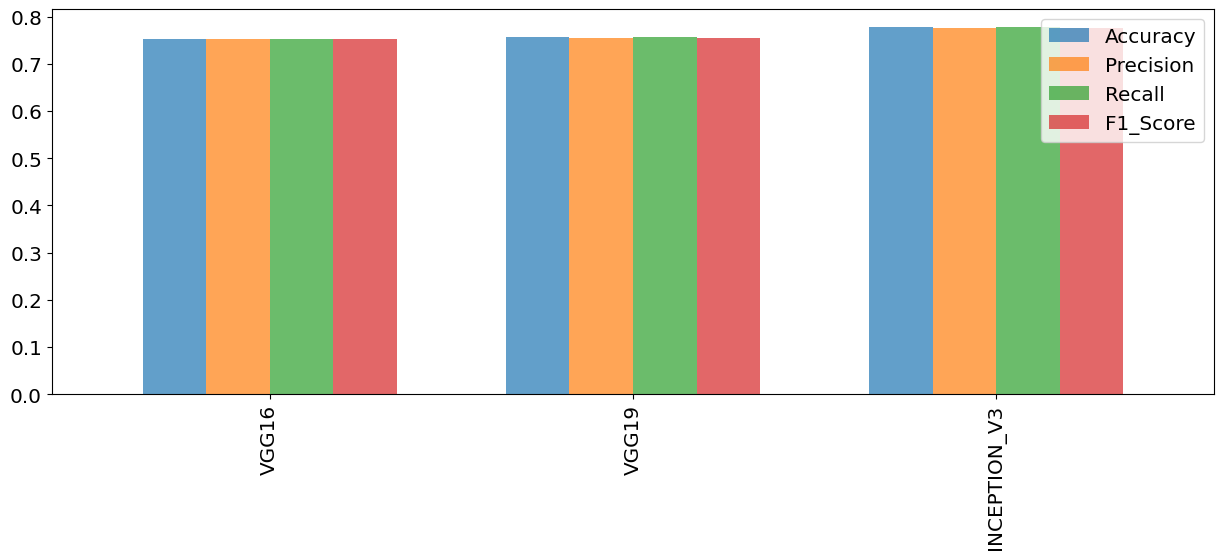

In [86]:
ErrorMetrics_df.plot.bar(width=0.7, alpha=0.7)